In [1]:
from src.dataloading import EpiConfig, EpiDataOrchestrator, CrossValidationEpiConfig, FoldCollection

In [2]:
cv_config = CrossValidationEpiConfig(
    min_date            = '2020-03-02',
    max_date            = '2023-01-01',
    num_folds           = 8,
    fold_step           = 1,
    train_periods       = 14,
    val_periods         = 6,
    test_periods        = 6,
    expansion_method    = 'rolling_window',
    unit                = 'm'
)


In [3]:
print(cv_config)

 Fold  |    Min Date    |   Train/Val    |    Val/Test    |    Max Date   
--------------------------------------------------------------------------
  0    |   2020-03-02   |   2021-05-02   |   2021-11-02   |   2022-05-02  
  1    |   2020-04-02   |   2021-06-02   |   2021-12-02   |   2022-06-02  
  2    |   2020-05-02   |   2021-07-02   |   2022-01-02   |   2022-07-02  
  3    |   2020-06-02   |   2021-08-02   |   2022-02-02   |   2022-08-02  
  4    |   2020-07-02   |   2021-09-02   |   2022-03-02   |   2022-09-02  
  5    |   2020-08-02   |   2021-10-02   |   2022-04-02   |   2022-10-02  
  6    |   2020-09-02   |   2021-11-02   |   2022-05-02   |   2022-11-02  
  7    |   2020-10-02   |   2021-12-02   |   2022-06-02   |   2022-12-02  


In [4]:
global_epiconfig = EpiConfig.load_config('default_covid_point_predictions')
# global_epiconfig.feature_gisd = False
# global_epiconfig.time_index_w = False

fold_collection = FoldCollection.build(cv_config, global_epiconfig)

EpiConfig default_covid_point_predictions loaded


data orchestrator per fold: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:07<00:00,  1.06it/s]


In [5]:
from src.dataloading import BaseLineDataLoaderManager

from src.models import PersistenceModel, ClimateologyModel

In [6]:
models = {}

for fold_idx, fold in enumerate(fold_collection):

    baseline_data            = BaseLineDataLoaderManager(fold.data_orch)
    
    persistence_predictor   = PersistenceModel(baseline_data,name   = f'fold{fold_idx+1}')
    climateology            = ClimateologyModel(baseline_data,name  = f'fold{fold_idx+1}')


    for ml in [persistence_predictor, climateology]:
        ml.train()
    
    persistence_predictor.forecast('test')
    climateology.forecast('test')

    models_fold = [persistence_predictor,climateology]
    models[f'fold{fold_idx+1}'] = models_fold

In [7]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

persistences    = []
climateologies  = []


for fold_idx, fold in enumerate(fold_collection):
    for model_idx, model in enumerate(models[f'fold{fold_idx + 1}']):
        if model.__class__.__name__ == 'PersistenceModel':
            persistences.append(model)
        if model.__class__.__name__ == 'ClimateologyModel':
            climateologies.append(model)


evaluators = {
    'persistence':  Evaluator(persistences).add_evaluation(),
    'climateology': Evaluator(climateologies).add_evaluation()
}

figure_raw1 = (evaluators['persistence'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'persistence', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators['climateology'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'climateology', fontweight='bold', fontsize=14)
            )


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3200/3200 [00:03<00:00, 804.70it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


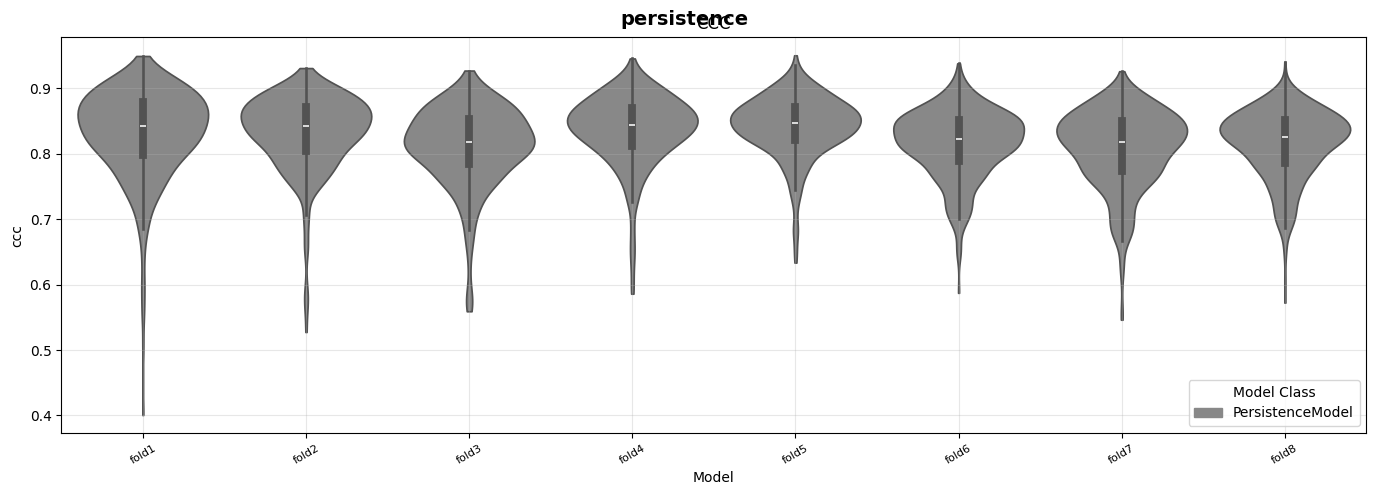

In [8]:
figure_raw1.show()


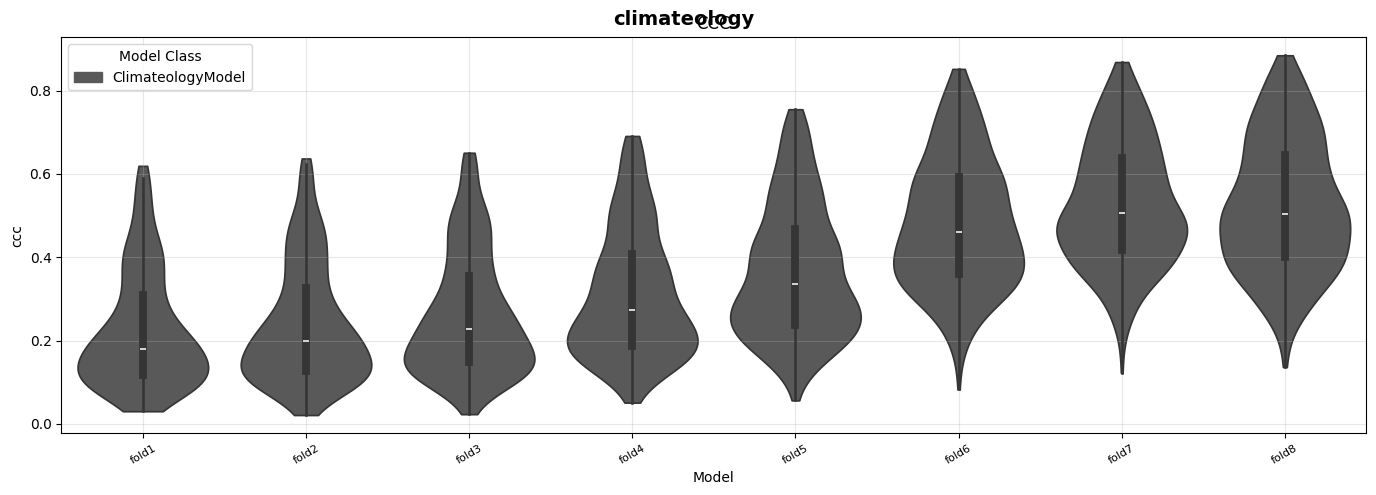

In [9]:
figure_raw2.show()

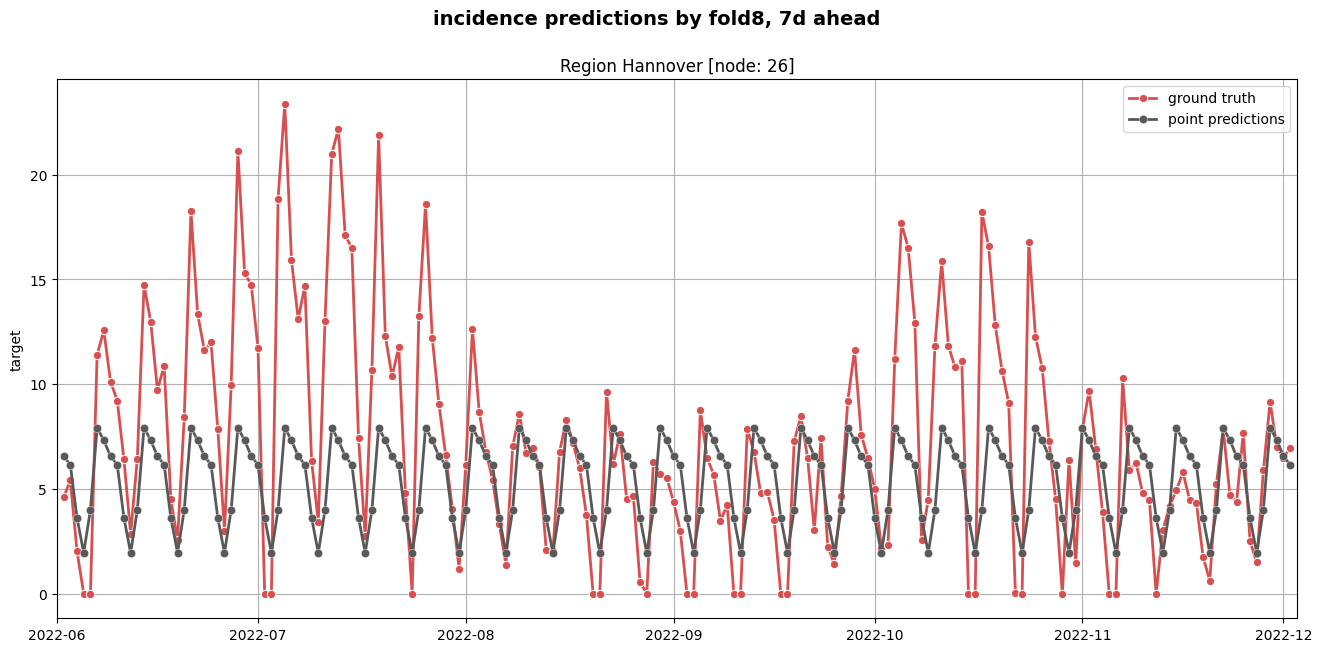

In [12]:
climateologies[7].show_forecasts(26).show()


==           identity_graph_gcn_fold1           ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 22, 7), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   1.1324   |   0.6905   |    v     |           |
|  002  |   1.0573   |   0.6527   |    v     |           |
|  003  |   0.9875   |   0.6125   |    v     |           |
|  004  |   0.9151   |   0.5708   |    v     |           |
|  005  |   0.8421   |   0.5287   |    v     |           |
|  006  |   0.7714   |   0.4879   |    v     |           |
|  007  |   0.7022   |   0.4471   |    v     |           |
|  008  |   0.6407   |   0.4089   |    v     |           |
|  009  |   0.5864   |   0.3753   |    v     |           |
|  010  |   0.5434   |   0.3464   |    v     |           |
|  011  |   0.5109   |   0.3236   |    v     |           |
|  012  |   0.4894   |   0.3064   |    v

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.2490
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 182/182 [00:00<00:00, 559.20it/s]


Test loss: 11.6644
forecasted ✓

==        geo-neighbors_graph_gcn_fold1         ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 22, 7), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.9775   |   0.6337   |    v     |           |
|  002  |   0.9339   |   0.6107   |    v     |           |
|  003  |   0.8881   |   0.5847   |    v     |           |
|  004  |   0.8343   |   0.5533   |    v     |           |
|  005  |   0.7722   |   0.5155   |    v     |           |
|  006  |   0.7015   |   0.4741   |    v     |           |
|  007  |   0.6321   |   0.4335   |    v     |           |
|  008  |   0.5655   |   0.3952   |    v     |           |
|  009  |   0.5062   |   0.3601   |    v     |           |
|  010  |   0.4562   |   0.3294   |    v     |           |
|  011  |   0.4175   |   0.3046   |    v     |           |
|  012

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.2509
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 182/182 [00:00<00:00, 544.83it/s]


Test loss: 21.3967
forecasted ✓


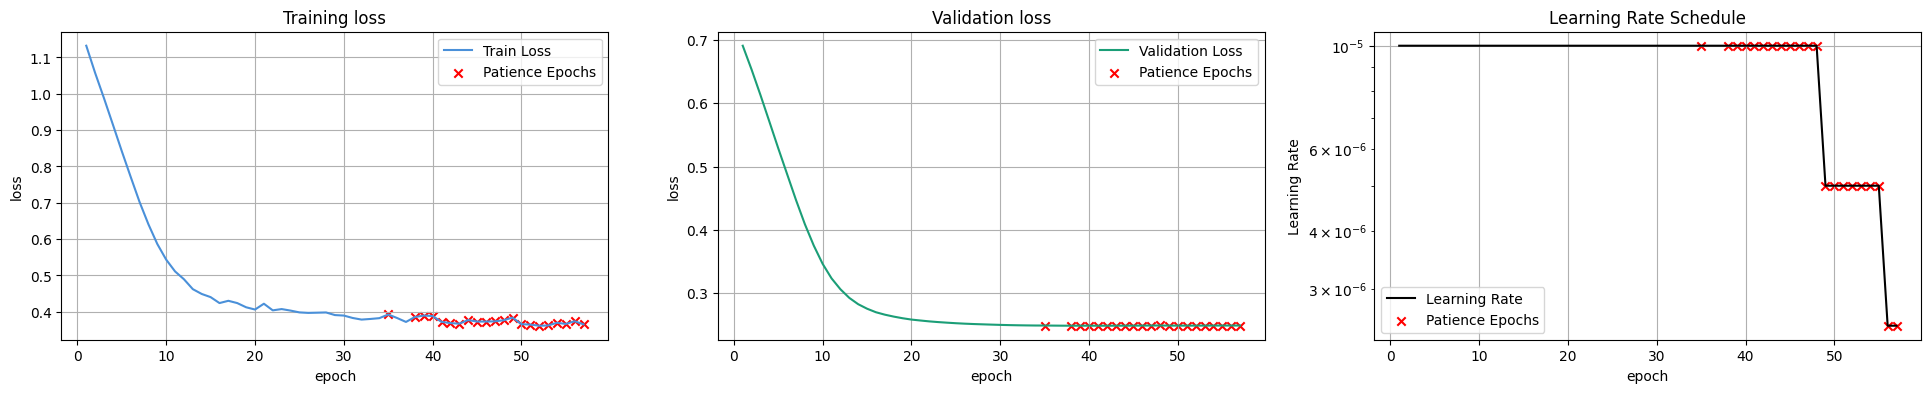

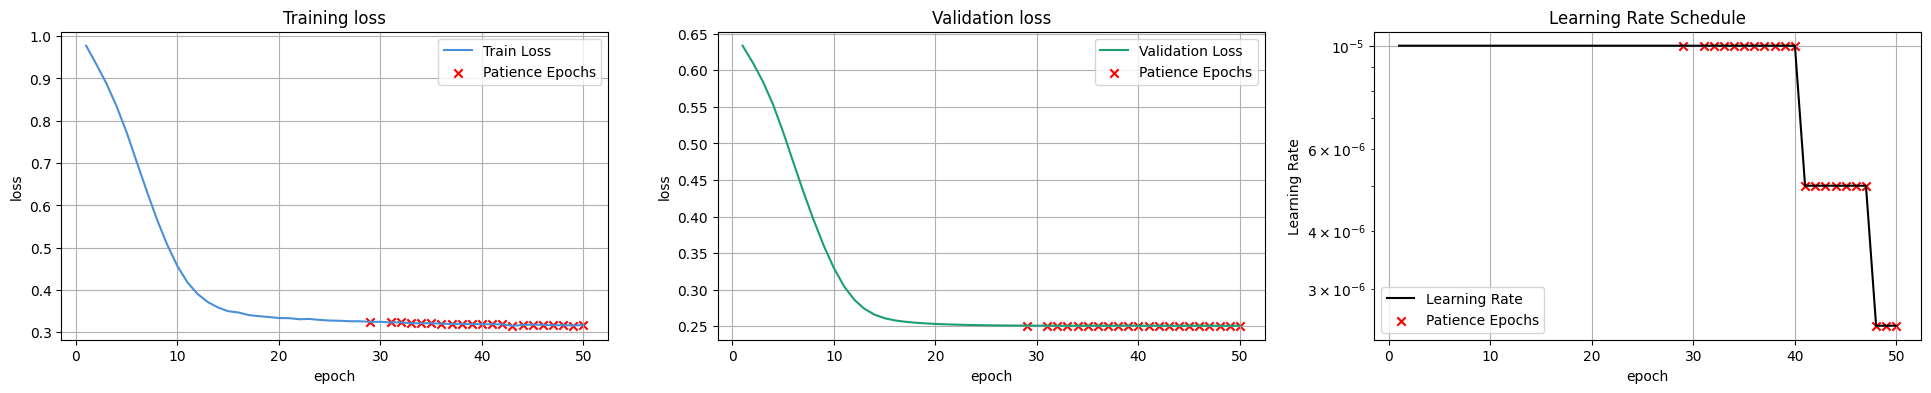

In [34]:
from src.models import SimpleGCNModel
from src.dataloading import GraphDataLoaderManager

n_epochs        = 500
lr              = 0.00001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

deepmodels = {}

for fold_idx, fold in enumerate(fold_collection):

    if fold_idx > 0:
        continue
    
    graphloader1            = GraphDataLoaderManager(fold.data_orch).retrieve_static_graph('identity_graph').build()
    gatv1   = SimpleGCNModel(graphloader1,name   = f'identity_graph_gcn_fold{fold_idx+1}', verbose = 2)
    gatv1.set_model_hparams()
    gatv1.set_global_hparams(**global_hparams)
    gatv1.train()
    gatv1.forecast()

    graphloader2            = GraphDataLoaderManager(fold.data_orch).retrieve_static_graph('geographical_neighbors1').build()   
    gatv2   = SimpleGCNModel(graphloader2,name   = f'geo-neighbors_graph_gcn_fold{fold_idx+1}', verbose = 2)
    gatv2.set_model_hparams()
    gatv2.set_global_hparams(**global_hparams)
    gatv2.train()
    gatv2.forecast()


    models_fold = [gatv1,gatv2]
    models[f'fold{fold_idx+1}'] = models_fold

In [17]:
igs

[]

In [35]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

igs    = []
gns  = []


for fold_idx, fold in enumerate(fold_collection):
    for model_idx, model in enumerate(models[f'fold{fold_idx + 1}']):
        if 'identity_graph_gcn_fold' in model.name:
            igs.append(model)
        if 'neighbors_graph_gcn_fold' in model.name:
            gns.append(model)

evaluators = {
    'ig':  Evaluator(igs).add_evaluation(),
    'gn': Evaluator(gns).add_evaluation()
}

figure_raw1 = (evaluators['ig'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'identity graph', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators['gn'].plotter.plot_single_metric('ccc',0,log=False,plot_type='violin')
            .change_figsize(14,5)
            # .layout.set_ylim([0,1])
            .labels.change_suptitle(f'geographical neighbors', fontweight='bold', fontsize=14)
            )


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:00<00:00, 784.65it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


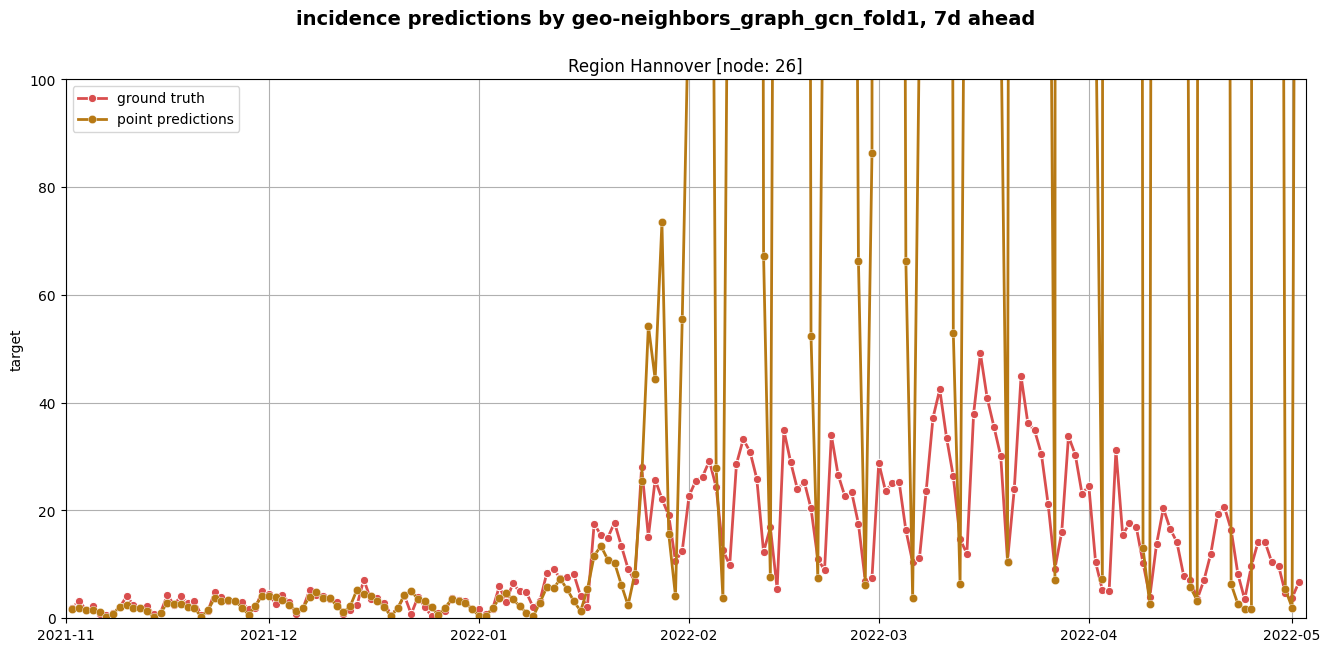

In [36]:
gns[0].show_forecasts(26).layout.set_ylim([0,100]).show()

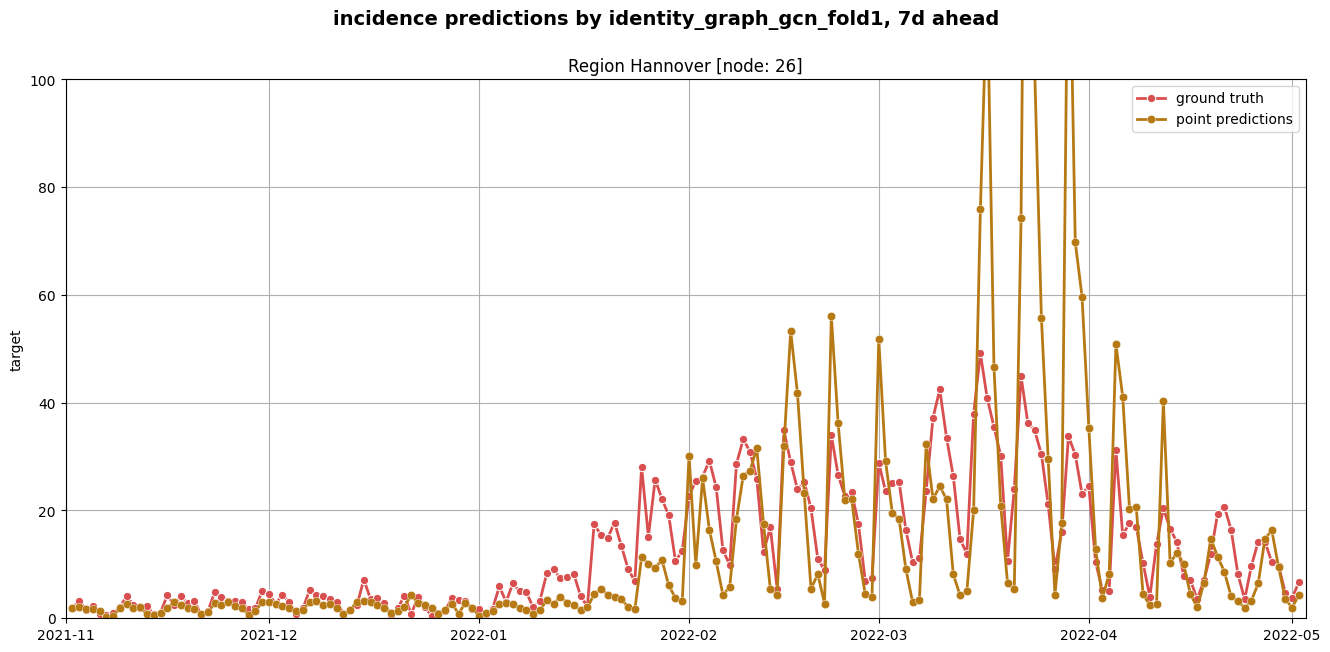

In [26]:
igs[0].show_forecasts(26).layout.set_ylim([0,100]).show()

In [28]:
igs[0].forecast('val')

Forecasting val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 184/184 [00:00<00:00, 560.21it/s]

Val loss: 0.2562
forecasted ✓


SimpleGCNModel(name='identity_graph_gcn_fold1')

In [29]:
gns[0].forecast('val')

Forecasting val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 184/184 [00:00<00:00, 548.46it/s]

Val loss: 0.2420
forecasted ✓


SimpleGCNModel(name='geo-neighbors_graph_gcn_fold1')

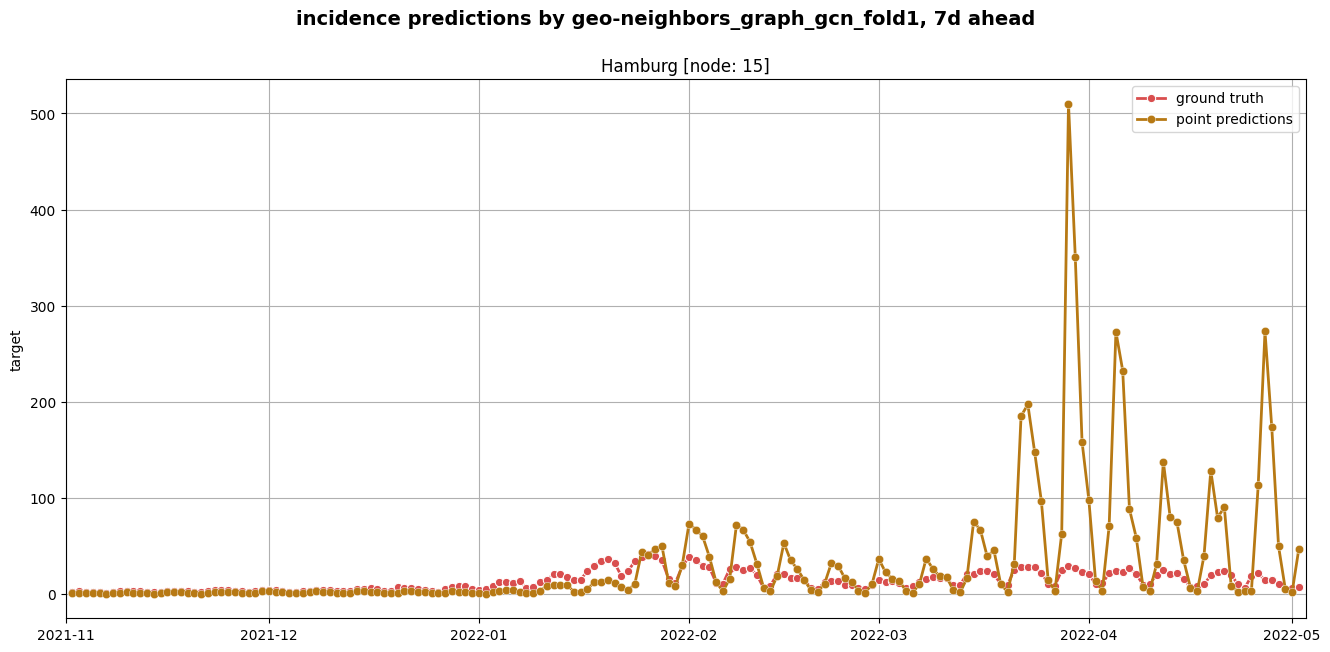

In [32]:
gns[0].show_forecasts(15).show()

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


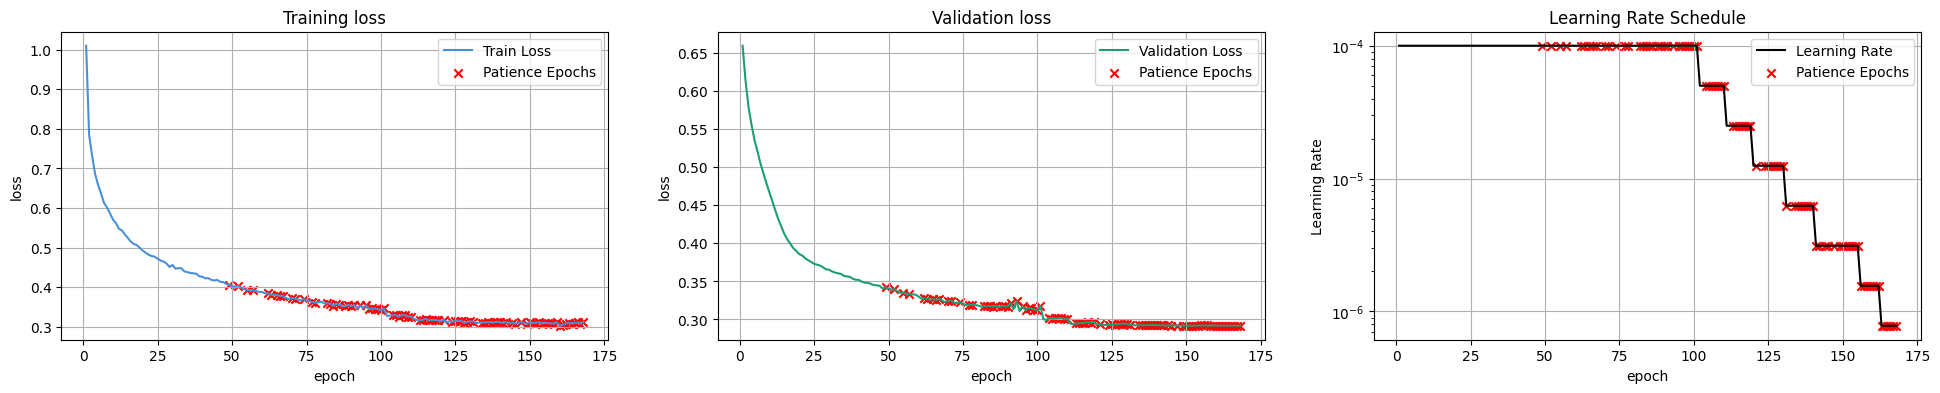

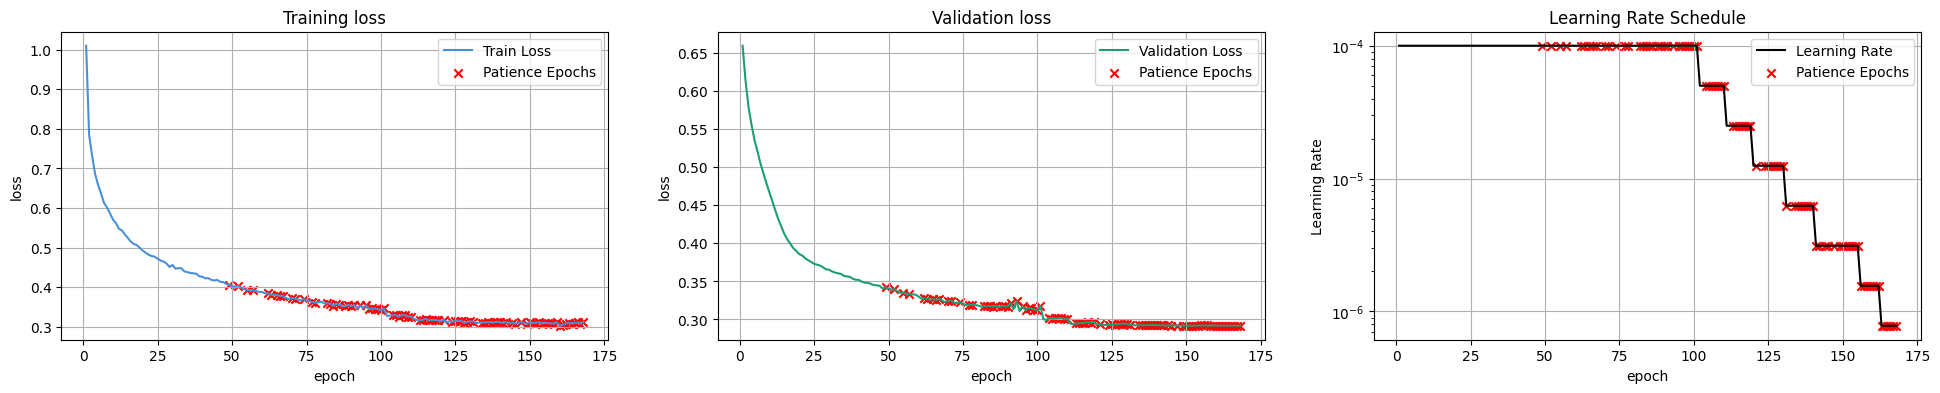

In [27]:
gns[5].show_monitoring_metrics()